In [1]:
from pycirclize import Circos
from pycirclize.utils import ColorCycler
import numpy as np
import pandas as pd
np.random.seed(0)
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

In [2]:
sample = 'SJOS001107_M2-SJOS001107_G1'
chromosomes_to_plot = ['chr6', 'chr9']

svs_file_all_samples = pd.read_csv('../../SV_signature_analysis/Clustered_SVs/data/sv_signature_analysis.bedpe', sep='\t')
svs_file_all_samples['chrom1'] = 'chr' + svs_file_all_samples['chrom1'].astype(str)
svs_file_all_samples['chrom2'] = 'chr' + svs_file_all_samples['chrom2'].astype(str)
# change 23 to X and 24 to Y
svs_file_all_samples['chrom1'] = svs_file_all_samples['chrom1'].replace('chr23', 'chrX')
svs_file_all_samples['chrom1'] = svs_file_all_samples['chrom1'].replace('chr24', 'chrY')
svs_file_all_samples['chrom2'] = svs_file_all_samples['chrom2'].replace('chr23', 'chrX')
svs_file_all_samples['chrom2'] = svs_file_all_samples['chrom2'].replace('chr24', 'chrY')

svs_file = svs_file_all_samples[svs_file_all_samples['sample'] == sample]

# filter chr_bed_file only to included chromosomes
chr_bed = pd.read_csv('../../SRB_analysis/data/hg38_ref_files/hg38_chr.bed', sep='\t')
chr_bed = chr_bed[chr_bed['#chrom'].isin(chromosomes_to_plot)]
chr_bed.to_csv('../data/chr_bed_filtered.bed', sep='\t', index=False)

# load cnvs
cnvs = pd.read_hdf('../../SV_sample_data/data/analysis_public_os_data_merged_abs_segfiles_v2.h5')
cnvs = cnvs[cnvs['sample'] == sample]
cnvs['Chromosome'] = 'chr' + cnvs['Chromosome'].astype(str)
cnvs = cnvs[cnvs['Chromosome'].isin(chromosomes_to_plot)]
cnvs['total_cn'] = cnvs['rescaled.cn.a1'] + cnvs['rescaled.cn.a2']
cnvs.head()

,sample,Chromosome,Start.bp,End.bp,subclonal.a1,subclonal.a2,cancer.cell.frac.a1,cancer.cell.frac.a2,rescaled.cn.a1,rescaled.cn.a2,total_cn
43943,SJOS001107_M2-SJOS001107_G1,chr6,150000.0,383999,1,0,0.76,0.18,0.0,2.99998,2.99998
43944,SJOS001107_M2-SJOS001107_G1,chr6,384000.0,2425999,0,1,1.00,0.60,0.0,4.00000,4.00000
43945,SJOS001107_M2-SJOS001107_G1,chr6,2464000.0,3493999,0,1,1.00,0.58,0.0,4.00000,4.00000
43946,SJOS001107_M2-SJOS001107_G1,chr6,3572000.0,24941999,0,1,1.00,0.51,0.0,4.99839,4.99839
43947,SJOS001107_M2-SJOS001107_G1,chr6,24954000.0,35149999,0,1,1.00,0.47,0.0,4.00000,4.00000


In [3]:
# filter svs file to only include SVs in chr6 or ch9, or translocations across
svs_file = svs_file[
    (svs_file['chrom1'].isin(chromosomes_to_plot)) &
    (svs_file['chrom2'].isin(chromosomes_to_plot))
]

diag = 'SJOS001107_D1-SJOS001107_G1'
met1 = 'SJOS001107_M1-SJOS001107_G1'
met2 = 'SJOS001107_M2-SJOS001107_G1'

key_cols = ['chrom1', 'start1', 'chrom2', 'start2']
met2_keys = svs_file[key_cols].drop_duplicates()

dm = svs_file_all_samples[svs_file_all_samples['sample'].isin([diag, met1])].copy()

# keep only events present in both samples
dm_both_keys = (
    dm.groupby(key_cols)['sample']
      .nunique()
      .reset_index(name='n_samples')
      .query('n_samples == 2')[key_cols]
)

# Intersect with met2 keys
shared_3way_keys = met2_keys.merge(dm_both_keys, on=key_cols, how='inner')

svs_met2_shared = svs_file.merge(shared_3way_keys, on=key_cols, how='inner')

print("Unique SV events in met2 that are also in both diag and met1:", len(shared_3way_keys))
print("Total SVs in met2:", len(svs_file))

Unique SV events in met2 that are also in both diag and met1: 19
Total SVs in met2: 41


25.828162443737


/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_4943/671728812.py:101: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


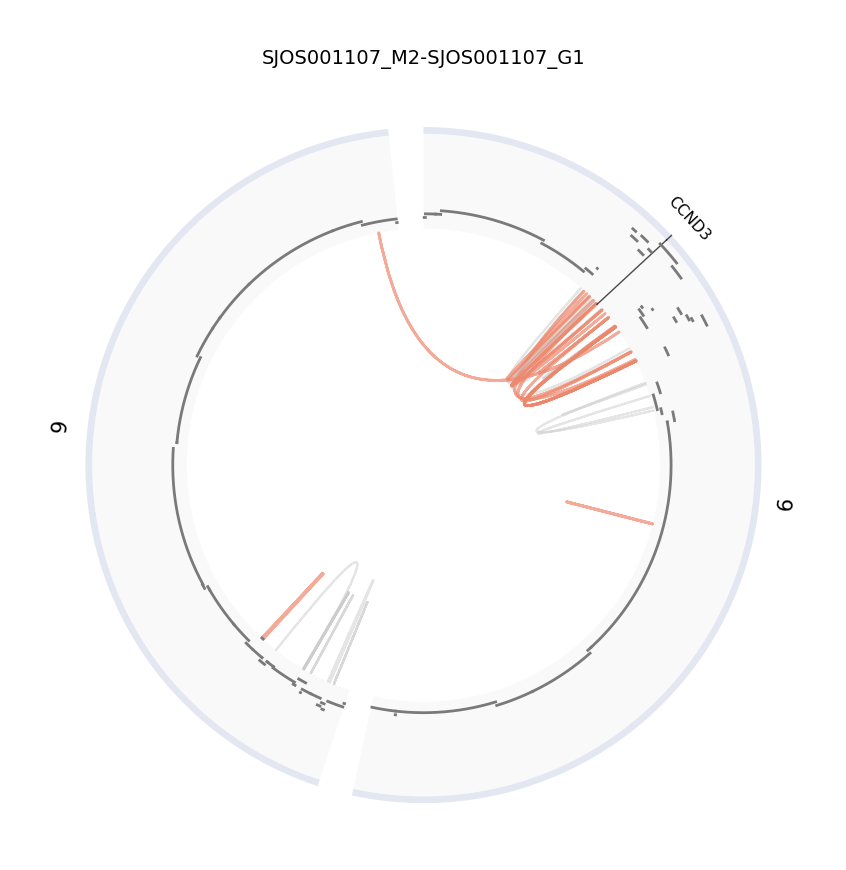

In [ ]:
circos = Circos.initialize_from_bed('../data/chr_bed_filtered.bed', space=6)
circos.text(sample, deg=0, r=120, size=14)

# Gene coordinates on hg38
genes = {
    #'CDKN2A': ('chr9', 21967752),
    'CCND3':  ('chr6', 41934933),
}

DEL_FRAC = 0.4 # Controls how much of the track height is reserved for deletions
DIPLOID = 2
CN_grid = [1, 5, 10, 15, 20]

def transform_cn(cn, cn_min, cn_max, diploid=DIPLOID, del_frac=DEL_FRAC):
    """Remap CN values so deletions occupy del_frac of visual track space."""
    visual_range = cn_max - cn_min
    del_space = del_frac * visual_range
    amp_space = (1 - del_frac) * visual_range

    if cn <= diploid:
        t = (cn - cn_min) / (diploid - cn_min)
        return cn_min + t * del_space
    else:
        t = (cn - diploid) / (cn_max - diploid)
        return cn_min + del_space + t * amp_space

svs_filtered = svs_file[
    svs_file['chrom1'].isin(chromosomes_to_plot) &
    svs_file['chrom2'].isin(chromosomes_to_plot)
].copy()

cn_min, cn_max = 0, (max(cnvs['total_cn']) + 2)
print("Max CN:", cn_max)

for sector in circos.sectors:
    # Outer arc
    outer_track = sector.add_track((98, 100))
    outer_track.axis(fc='#e3e7f2', ec='#eeeeee', lw=0)
    sector.text(sector.name.replace('chr', ''), size=15)

    # CNV track
    cnv_track = sector.add_track((70, 98), r_pad_ratio=0)
    cnv_track.axis(fc='#f5f5f5', alpha = 0.5, ec='none', lw=0, rasterized=True)
    chr_cnvs = cnvs[cnvs['Chromosome'] == sector.name].sort_values('Start.bp')

    for gene, (chrom, pos) in genes.items():
        if chrom == sector.name:
            # Vertical line in each track by using same x, spanning full y range
            outer_track.line([pos, pos], [0, 1], vmin=0, vmax=1,
                             color='black', lw=1, alpha=0.7)
            cnv_track.line([pos, pos], [cn_min, cn_max], vmin=cn_min, vmax=cn_max,
                           color='black', lw=1, alpha=0.7)
            sector.text(gene, x=pos, r=105, size=11, color='black', adjust_rotation=True)

    # Horizontal segment lines in black
    for _, cnv in chr_cnvs.iterrows():
        cn = min(cnv['total_cn'], cn_max)
        cnv_track.line(
            [cnv['Start.bp'], cnv['End.bp']],
            [cn, cn],
            vmin=0,
            vmax=cn_max,
            color='#7a7a7a',
            lw=2
        )

    cn_max_label = round(cn_max - 2, 0)
    if sector.name == 'chr15':
        cnv_track.yticks(
            [0, cn_max_label],
            labels=[str(int(cn_min)), str(int(cn_max_label))],
            vmin=0,
            vmax=cn_max,
            tick_length=1,
            label_size=11,
        )

shared_key_set = set(
    tuple(row) for row in shared_3way_keys[key_cols].drop_duplicates().itertuples(index=False, name=None)
)

for sv in svs_filtered.itertuples(index=False):
    region1 = (sv.chrom1, sv.start1, sv.end1)
    region2 = (sv.chrom2, sv.start2, sv.end2)

    sv_key = (sv.chrom1, sv.start1, sv.chrom2, sv.start2)
    is_truncal = sv_key in shared_key_set

    color = '#ee876cdb' if is_truncal else '#CCCCCC'
    alpha = 0.7 if is_truncal else 0.5
    lw = 2 if is_truncal else 1.5

    circos.link(region1, region2, color=color, lw=lw, alpha=alpha)

fig = circos.plotfig()
fig.savefig(f'../results/{sample}_circos_plot.svg', dpi=600, bbox_inches='tight')
fig.show()